# 02 – Bias Detection and Fairness Analysis
NovaCred Credit Application Dataset

## Goal

This notebook analyzes potential algorithmic bias in NovaCred’s historical credit application dataset.
While the previous notebook focused on data quality issues, this analysis examines whether historical lending decisions exhibit systematic disparities across demographic groups.

In particular, we evaluate whether the dataset reflects patterns of discrimination or structural bias that could lead to unfair outcomes if used to train machine learning models.
Furthermore we will complement the traditional Data Quality dimensions by looking more closely into Fairness Metrics. 

## Objective
| Analysis Area       | Description                                                                                      |
| ------------------- | ------------------------------------------------------------------------------------------------ |
| Historical Bias     | Investigate whether past credit decisions reflect historical inequalities encoded in the dataset |
| Selection Bias      | Examine whether certain demographic groups are over- or under-represented in the dataset         |
| Measurement Bias    | Identify variables that may act as imperfect proxies for creditworthiness                        |
| Aggregation Bias    | Evaluate whether patterns differ across demographic groups, particularly age segments            |
| Fairness Metrics    | Measure potential gender disparities using the **Disparate Impact Ratio (80% rule)**             |
| Interaction Effects | Explore combined effects between variables such as age, gender, and financial characteristics    |

## Structure 
0. Initial Data Collection
1. Analysis of Bias Types
2. Fairness Metrics 
3. Interactions

## **0. Initial Data Collection**

In [80]:
# Placeholder: import libraries
import pandas as pd
import numpy as np
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt

# TODO: replace with real data loading and analysis steps

In [81]:
# Load cleaned dataset
df = pd.read_csv("../data/cleaned_credit_applications.csv")

# Quick check
df.head()

,_id,spending_behavior,processing_timestamp,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount
0,app_246,"[{'category': 'Healthcare', 'amount': 478}]",NaN,female,1991-10-11,90223.0,82000.0,31.0,0.29,21809.0,True,NaN,auto,2.8,38000.0
1,app_163,"[{'category': 'Shopping', 'amount': 404}]",2024-01-15T00:00:00Z,male,1981-06-03,10019.0,104000.0,58.0,0.30,38425.0,True,NaN,unknown,2.9,47000.0
2,app_214,"[{'category': 'Utilities', 'amount': 786}]",NaN,female,1962-08-26,90277.0,116000.0,84.0,0.31,41962.0,True,NaN,debt_consolidation,4.1,57000.0
3,app_177,"[{'category': 'Shopping', 'amount': 392}]",2024-01-15T00:00:00Z,male,1990-01-25,10004.0,54000.0,35.0,0.05,25705.0,True,NaN,unknown,5.9,67000.0
4,app_235,"[{'category': 'Travel', 'amount': 886}]",NaN,male,1997-08-31,10012.0,22000.0,16.0,0.28,12134.0,True,NaN,medical,5.4,39000.0


## **1. Analysis of Bias Types**

### **1.1. Age-Based Bias**

In [82]:
# Convert date_of_birth to datetime
df["applicant_info.date_of_birth"] = pd.to_datetime(df["applicant_info.date_of_birth"])

# Calculate age using timestamp difference
df["age"] = ((pd.Timestamp.today() - df["applicant_info.date_of_birth"]).dt.days / 365.25).round(1)

# Check result
df["age"].describe()

count    496.000000
mean      41.236492
std       10.930050
min       23.900000
25%       32.475000
50%       39.650000
75%       47.525000
max       67.500000
Name: age, dtype: float64

In [83]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[18, 25, 35, 45, 55, 65, 101],
    labels=["18-24", "25-34", "35-44", "45-54", "55-64", "65+"],
    right=False
)
df["age_group"].value_counts().sort_index()

age_group
18-24     10
25-34    150
35-44    178
45-54     89
55-64     56
65+       13
Name: count, dtype: int64

In [84]:
overall_approval_rate = df["decision.loan_approved"].mean()
print("Overall approval rate:", round(overall_approval_rate, 3))

approved_df = df[df["decision.loan_approved"] == True]

Overall approval rate: 0.584


In [99]:
approval_by_age = (
    df.groupby("age_group")["decision.loan_approved"]
    .mean().round(2)
)

approval_summary = approval_by_age.reset_index()
approval_summary["overall_avg"] = overall_approval_rate.round(2)

approval_summary["diff_from_avg"] = (
    approval_summary["decision.loan_approved"] - overall_approval_rate
).round(2)

approval_summary

C:\Users\Behnia\AppData\Local\Temp\ipykernel_11076\1405855041.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["decision.loan_approved"]


,age_group,decision.loan_approved,overall_avg,diff_from_avg
0,18-24,0.50,0.58,-0.08
1,25-34,0.45,0.58,-0.13
2,35-44,0.66,0.58,0.08
3,45-54,0.64,0.58,0.06
4,55-64,0.62,0.58,0.04
5,65+,0.54,0.58,-0.04


In [87]:
overall_interest = approved_df["decision.interest_rate"].mean()
print("Overall average interest rate:", round(overall_interest, 3))

Overall average interest rate: 4.565


In [100]:
interest_by_age = (
    approved_df.groupby("age_group")["decision.interest_rate"]
    .mean().round(2)
)

interest_summary = interest_by_age.reset_index()
interest_summary["overall_avg"] = overall_interest.round(2)

# deviation from overall average
interest_summary["diff_from_avg"] = (
    interest_summary["decision.interest_rate"] - interest_summary["overall_avg"]
).round(2)

interest_summary

C:\Users\Behnia\AppData\Local\Temp\ipykernel_11076\2153335548.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  approved_df.groupby("age_group")["decision.interest_rate"]


,age_group,decision.interest_rate,overall_avg,diff_from_avg
0,18-24,4.54,4.56,-0.02
1,25-34,4.42,4.56,-0.14
2,35-44,4.55,4.56,-0.01
3,45-54,4.68,4.56,0.12
4,55-64,4.51,4.56,-0.05
5,65+,5.37,4.56,0.81


C:\Users\Behnia\AppData\Local\Temp\ipykernel_11076\3163098807.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["decision.loan_approved"]
C:\Users\Behnia\AppData\Local\Temp\ipykernel_11076\3163098807.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  approved_df.groupby("age_group")["decision.interest_rate"]


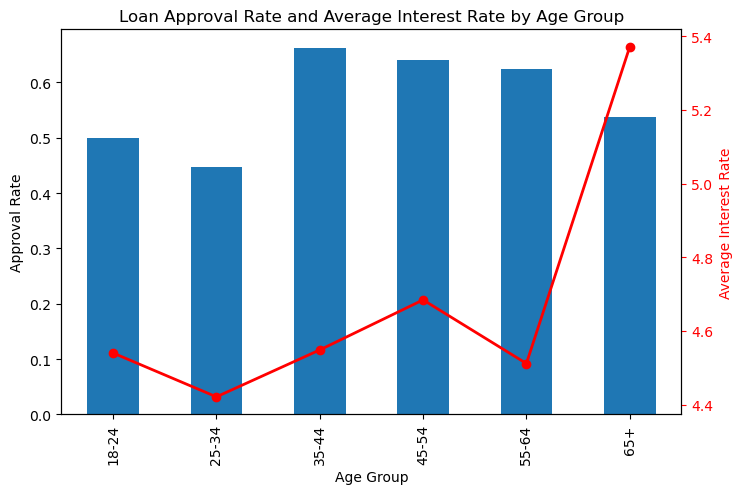

In [106]:
# approval rate per age group
approval_rate = (
    df.groupby("age_group")["decision.loan_approved"]
    .mean()
)

# average interest rate for approved loans
avg_interest = (
    approved_df.groupby("age_group")["decision.interest_rate"]
    .mean()
)

fig, ax1 = plt.subplots(figsize=(8,5))

# bar chart → approval rate
approval_rate.plot(
    kind="bar",
    ax=ax1
)

ax1.set_xlabel("Age Group")
ax1.set_ylabel("Approval Rate")
ax1.set_title("Loan Approval Rate and Average Interest Rate by Age Group")

# second axis → interest rate
ax2 = ax1.twinx()

ax2.plot(
    avg_interest.index,
    avg_interest.values,
    marker="o",
    linewidth=2,
    color="red"
)

ax2.set_ylabel("Average Interest Rate", color="red")
ax2.tick_params(axis='y', colors='red')

plt.show()

In [92]:
overall_amount = approved_df["decision.approved_amount"].mean()
print("Overall average approved amount:", round(overall_amount, 2))

Overall average approved amount: 47845.89


In [101]:
amount_by_age = (
    approved_df.groupby("age_group")["decision.approved_amount"]
    .mean().round(2)
)

amount_summary = amount_by_age.reset_index()
amount_summary["overall_avg"] = overall_amount.round(2)

# deviation from overall average
amount_summary["diff_from_avg"] = (
    amount_summary["decision.approved_amount"] - amount_summary["overall_avg"]
).round(2)

amount_summary

C:\Users\Behnia\AppData\Local\Temp\ipykernel_11076\1120276433.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  approved_df.groupby("age_group")["decision.approved_amount"]


,age_group,decision.approved_amount,overall_avg,diff_from_avg
0,18-24,34600.00,47845.89,-13245.89
1,25-34,47985.07,47845.89,139.18
2,35-44,47550.85,47845.89,-295.04
3,45-54,47526.32,47845.89,-319.57
4,55-64,48914.29,47845.89,1068.40
5,65+,58428.57,47845.89,10582.68


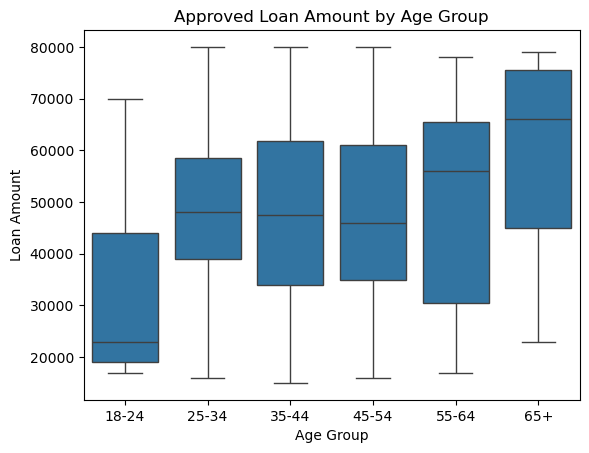

In [86]:
sns.boxplot(
    data=approved_df,
    x="age_group",
    y="decision.approved_amount"
)

plt.title("Approved Loan Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Loan Amount")
plt.show()

### **1.2. Measurement Bias Analysis** (Proxy Discrimination)

### **1.3. Selection Bias** (Nach vorne schieben)